# Fit pairwise copying model to experiment data with spatial DoFs (i.e. dynamic subgroups)
See Puri, et. al, PRL (2026) Supplementary Material (Sec. 3) for details of the fitting procedure 


### Hyper parameters used
- $\tau$ (subgroup stability threshold) = 250 frames (~2.1s)
- $L$ (interaction length) = 50mm. Additional sensitivity analysis using $L$ = 40mm, 50mm, 60mm, 70mm
- Sample size for subsampling experiemnts = N_exp/2 for each age [5,4,5,4 experiments respectively], and we consider all possible subsamples 


In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import seaborn as sns
import datetime
from scipy.special import comb
from itertools import combinations

import sys
sys.path.append('../..')
from codebase.subgroup_analysis import annotate_subgroups_framewise
from codebase.parameter_fitting import (get_polarization_by_subgroup_size, get_autocorrelation_and_avg_timescale, 
                                        get_first_jump_moments, get_second_jump_moments, fit_alpha_beta_jointly_from_first_second_jump_moments)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
data_path = '../../Data/groups_by_age/'
exp_details = pd.read_csv(data_path + 'exp_details.csv')
fish_ages = [2,4,6,8]

tau = 250 #frames, existence time threshold for subgroup stability 
L_list = [40, 50, 60, 70] #interaction distance in mm


# First compute subgroup polarization for each experiment and each value of $L$

In [17]:
subgroup_polarization_all_ages_all_L = {L: {age: [] for age in fish_ages} for L in L_list}

for L in L_list:
    for j,age in enumerate(fish_ages):
        exp_list = np.flatnonzero(exp_details['fish_age']==age)
        subgroup_polarization_expwise = [] 
        
        for exp in exp_list:
            fpath = f'{data_path}h5_files_cleaned/{exp_details["experiment"][exp]}.h5'
            f = h5py.File(fpath,'r')
            nfish = 4

            x = f['tracks'][:nfish,0,:,:] # array of shape (fish x nodes x frames)
            y = f['tracks'][:nfish,1,:,:]
            nose_x = (x[:,0,:] + x[:,1,:])/2 # avg L and R eye positions to get nose position
            nose_y = (y[:,0,:] + y[:,1,:])/2

            # heading angles by calculating angle between nose and mid-bladder (node index 3)
            # mid-bladder is a more stable reference point than tail 
            head_angles_all_fish = np.arctan2(nose_y - y[:,3,:], nose_x - x[:,3,:])

            subgroups, start_end_frames = annotate_subgroups_framewise(nose_x, nose_y, L)

            subgroup_sizes = np.array([len(s) for s in subgroups])
            subgroup_durations = start_end_frames[:,1] - start_end_frames[:,0]
            # drop N=1 (single fish) subgroups and subgroups that are shortlived (duration < tau)
            selected_idx = np.flatnonzero((subgroup_sizes > 1) & (subgroup_durations >= tau))
            
            subgroups = [subgroups[i] for i in selected_idx]
            start_end_frames = start_end_frames[selected_idx,:]

            polarization_by_size = get_polarization_by_subgroup_size(subgroups, start_end_frames, head_angles_all_fish)
            subgroup_polarization_expwise.append(polarization_by_size)

        subgroup_polarization_all_ages_all_L[L][age] = subgroup_polarization_expwise

# Step 1: Choose $\Delta t_1$ using autocorrelation timescale of polarization

In [ ]:
autocorrelation_timescale = np.zeros((len(L_list), len(fish_ages), 3)) # store timescales for each L, age, (N=2,3,4)
Ng_values = [2,3,4]
for i, L in enumerate(L_list):
    for j, age in enumerate(fish_ages):
        subgroup_polarization_expwise = subgroup_polarization_all_ages_all_L[L][age]
        for k, Ng in enumerate(Ng_values):
            subgroup_polarization_N = []
            for m in range(len(subgroup_polarization_expwise)):
                subgroup_polarization_N.extend(subgroup_polarization_expwise[m][Ng])
            _, timescale = get_autocorrelation_and_avg_timescale(subgroup_polarization_N, dt_array=np.arange(0,tau,1))
            autocorrelation_timescale[i,j,k] = int(timescale)

# choose delta_t_1 by averaging timescales across N
delta_t_1 = np.mean(autocorrelation_timescale, axis=2).astype(int) # shape (len(L_list), len(fish_ages))
for i, L in enumerate(L_list):
    for j, age in enumerate(fish_ages):
        print(f"L={L}, age={age}wpf, dt1={delta_t_1[i,j]:.0f} frames")

/Users/palka/Documents/Research/fish-school/data-analysis/fish-project/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/palka/Documents/Research/fish-school/data-analysis/fish-project/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/palka/Documents/Research/fish-school/data-analysis/fish-project/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


L=40, age=2wpf, dt1=55 frames
L=40, age=4wpf, dt1=63 frames
L=40, age=6wpf, dt1=79 frames
L=40, age=8wpf, dt1=102 frames
L=50, age=2wpf, dt1=62 frames
L=50, age=4wpf, dt1=63 frames
L=50, age=6wpf, dt1=93 frames
L=50, age=8wpf, dt1=103 frames
L=60, age=2wpf, dt1=62 frames
L=60, age=4wpf, dt1=70 frames
L=60, age=6wpf, dt1=101 frames
L=60, age=8wpf, dt1=119 frames
L=70, age=2wpf, dt1=67 frames
L=70, age=4wpf, dt1=70 frames
L=70, age=6wpf, dt1=105 frames
L=70, age=8wpf, dt1=132 frames


# Step 2: Choose $\Delta t_2$ that results in the highest $R^2$ for the fit

In [ ]:
dt2_list = np.arange(1,200,1) 

alpha_beta_fit_results_all_Ng_all_dt2= np.zeros((len(L_list), len(fish_ages), len(dt2_list), len(Ng_values), 2)) #L, age, dt2, N, (alpha,beta)
r_squared_all_Ng_all_dt2 = np.zeros((len(L_list), len(fish_ages), len(dt2_list), len(Ng_values))) #L, age, dt2, N, R^2

for i, L in enumerate(L_list):
    for j,age in enumerate(fish_ages):
        for k,Ng in enumerate(Ng_values):
            # combine experiments to find subgroup polarization for full dataset
            subgroup_polarization = []
            for ind in range(len(subgroup_polarization_all_ages_all_L[L][age])):
                subgroup_polarization.extend(subgroup_polarization_all_ages_all_L[L][age][ind][Ng])
            dt1 = delta_t_1[i,j] # optimal dt1 choice based on autocorrelation time

            # find first jump moments
            first_jump_moments = get_first_jump_moments(subgroup_polarization, dt1)
            
            for l,dt2 in enumerate(dt2_list):
                # calculate second jump moments
                second_jump_moments = get_second_jump_moments(subgroup_polarization, dt2)
                # fit alpha and beta jointly
                alpha_fit, beta_fit, r_squared = fit_alpha_beta_jointly_from_first_second_jump_moments(first_jump_moments, second_jump_moments, Ng)
                r_squared_all_Ng_all_dt2[i,j,l,k] = r_squared
                alpha_beta_fit_results_all_Ng_all_dt2[i,j,l,k,:] = [alpha_fit, beta_fit]
            print(f'L: {L}mm, Age: {age}wpf, Ng: {Ng} completed at {datetime.datetime.now().strftime("%H:%M:%S")}')

r_squared_avg_over_N = np.mean(r_squared_all_Ng_all_dt2, axis=3) # average R^2 over Ng values, shape (len(L_list), len(fish_ages), len(dt2_list))


/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:161: RuntimeWarning: invalid value encountered in sqrt
  B_xy2 = dmxy**2 / ((dmxx+dmyy)+2*np.sqrt(dmxx*dmyy-dmxy**2))
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:162: RuntimeWarning: invalid value encountered in sqrt
  B_xx2 = (dmxx + np.sqrt(dmxx*dmyy-dmxy**2))**2/((dmxx+dmyy)+2*np.sqrt(dmxx*dmyy-dmxy**2))
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:163: RuntimeWarning: invalid value encountered in sqrt
  B_yy2 = (dmyy + np.sqrt(dmxx*dmyy-dmxy**2))**2/((dmxx+dmyy)+2*np.sqrt(dmxx*dmyy-dmxy**2))


L: 40mm, Age: 2wpf, N: 2 completed at 13:39:26
L: 40mm, Age: 2wpf, N: 3 completed at 13:39:39
L: 40mm, Age: 2wpf, N: 4 completed at 13:39:46
L: 40mm, Age: 4wpf, N: 2 completed at 13:39:59
L: 40mm, Age: 4wpf, N: 3 completed at 13:40:11
L: 40mm, Age: 4wpf, N: 4 completed at 13:40:25
L: 40mm, Age: 6wpf, N: 2 completed at 13:40:53
L: 40mm, Age: 6wpf, N: 3 completed at 13:41:12
L: 40mm, Age: 6wpf, N: 4 completed at 13:41:33
L: 40mm, Age: 8wpf, N: 2 completed at 13:41:48
L: 40mm, Age: 8wpf, N: 3 completed at 13:41:55
L: 40mm, Age: 8wpf, N: 4 completed at 13:42:10
L: 50mm, Age: 2wpf, N: 2 completed at 13:42:40
L: 50mm, Age: 2wpf, N: 3 completed at 13:42:56
L: 50mm, Age: 2wpf, N: 4 completed at 13:43:08
L: 50mm, Age: 4wpf, N: 2 completed at 13:43:20
L: 50mm, Age: 4wpf, N: 3 completed at 13:43:32
L: 50mm, Age: 4wpf, N: 4 completed at 13:43:51
L: 50mm, Age: 6wpf, N: 2 completed at 13:44:12
L: 50mm, Age: 6wpf, N: 3 completed at 13:44:31
L: 50mm, Age: 6wpf, N: 4 completed at 13:45:04
L: 50mm, Age:

#### Find optimal dt2 as the first derivative zero crossing

L=40, age=2wpf, dt2=31 frames
L=40, age=4wpf, dt2=13 frames
L=40, age=6wpf, dt2=13 frames
L=40, age=8wpf, dt2=12 frames
L=50, age=2wpf, dt2=47 frames
L=50, age=4wpf, dt2=21 frames
L=50, age=6wpf, dt2=12 frames
L=50, age=8wpf, dt2=9 frames
L=60, age=2wpf, dt2=23 frames
L=60, age=4wpf, dt2=23 frames
L=60, age=6wpf, dt2=12 frames
L=60, age=8wpf, dt2=9 frames
L=70, age=2wpf, dt2=19 frames
L=70, age=4wpf, dt2=21 frames
L=70, age=6wpf, dt2=12 frames
L=70, age=8wpf, dt2=10 frames


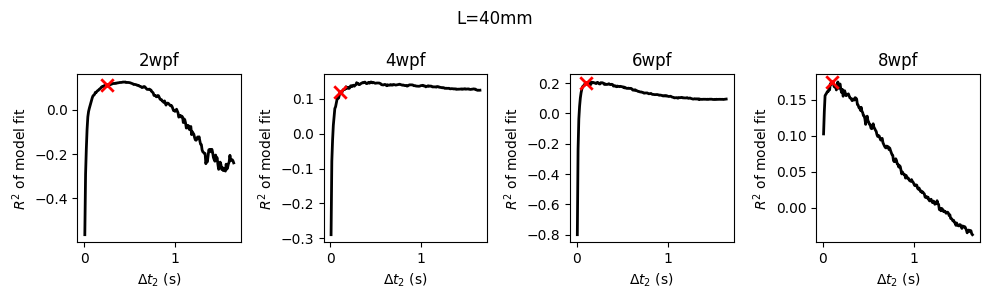

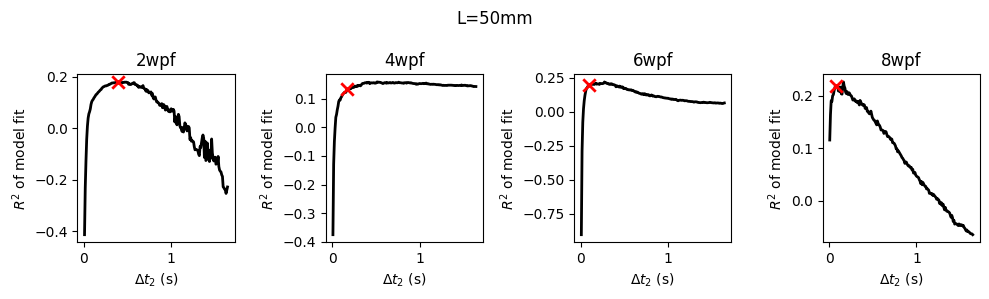

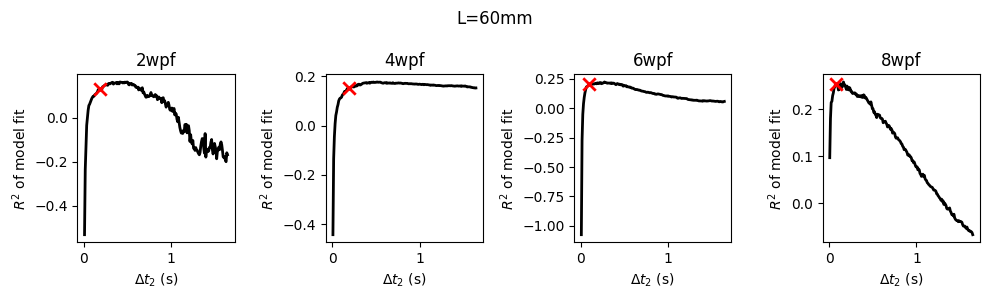

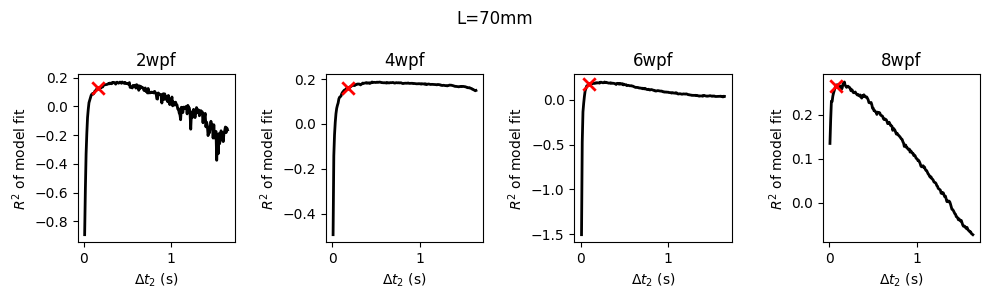

In [20]:
delta_t_2 = np.zeros((len(L_list), len(fish_ages)), dtype=int) 
delta_t_2_indices = np.zeros((len(L_list), len(fish_ages)), dtype=int)
fps = 121
for i, L in enumerate(L_list):
    fig, ax = plt.subplots(1,4, figsize=(10,3))
    fig.suptitle(f'L={L}mm')
    for j, age in enumerate(fish_ages):
        y = r_squared_avg_over_N[i,j,:]
        first_derivative = np.gradient(y)
        # location where first derivative crosses zero
        idx = np.flatnonzero(np.diff(np.sign(first_derivative))<0)[0]
        delta_t_2[i,j] = dt2_list[idx]
        delta_t_2_indices[i,j] = idx
        print(f"L={L}, age={age}wpf, dt2={delta_t_2[i,j]:.0f} frames")
        ax[j].plot(dt2_list/fps, y, label=r'$R^2$', color='k', linewidth=2)
        ax[j].scatter(dt2_list[idx]/fps, y[idx], color='r', s=80, marker='x', label='First Derivative Zero Crossing', linewidth=2,zorder=10)
        ax[j].set_title(f'{fish_ages[j]}wpf')
        ax[j].set_xlabel(r'$\Delta t_2$ (s)')
        ax[j].set_ylabel('$R^2$ of model fit')

    fig.tight_layout()

# Step 3: Extract parameter fits for optimal $\Delta t_{1,2}$ for each age & $L$

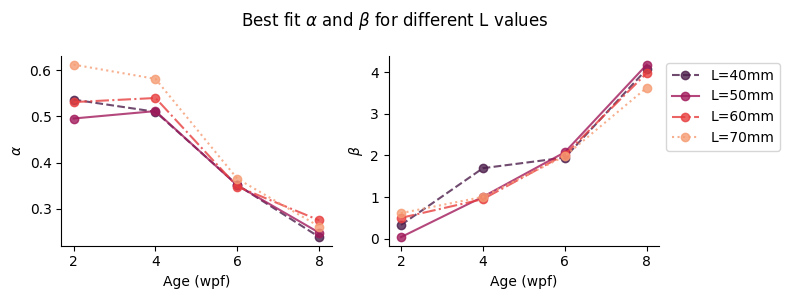

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
colors = sns.color_palette("rocket", n_colors=len(L_list))
linestyles=["--", "-", "-.", ":"]

for i, L in enumerate(L_list):
    indices = delta_t_2_indices[i,:]
    alphas = np.mean(alpha_beta_fit_results_all_Ng_all_dt2[i,range(len(fish_ages)),indices,:,0], axis=1)
    betas = np.mean(alpha_beta_fit_results_all_Ng_all_dt2[i,range(len(fish_ages)),indices,:,1], axis=1) 
    ax[0].plot(fish_ages, alphas, marker='o', label=f'L={L}mm', color=colors[i], linewidth=1.5, alpha=0.8, linestyle=linestyles[i])
    ax[1].plot(fish_ages, betas, marker='o', label=f'L={L}mm', color=colors[i], linewidth=1.5, alpha=0.8, linestyle=linestyles[i])
ax[0].set_xlabel('Age (wpf)')
ax[0].set_ylabel(r'$\alpha$')
ax[1].set_xlabel('Age (wpf)')
ax[1].set_ylabel(r'$\beta$')
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1))
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
fig.suptitle(r'Best fit $\alpha$ and $\beta$ for different L values')
fig.tight_layout()


# Step 4: Obtain error bars by subsampling experiments

### First compute jump moments for each experiment individually

In [ ]:
first_jump_moments_all_L = {L: {} for L in L_list}
second_jump_moments_all_L = {L: {} for L in L_list}
for i, L in enumerate(L_list):
    for j, age in enumerate(fish_ages):
        subgroup_polarization_expwise = subgroup_polarization_all_ages_all_L[L][age]
        N_exp = len(subgroup_polarization_expwise)
        dt1 = delta_t_1[i,j]
        dt2 = delta_t_2[i,j]
        first_jump_moments_all_exp = []
        second_jump_moments_all_exp = []

        for m in range(N_exp):
            first_jump_moments= []
            second_jump_moments = []
            for Ng in Ng_values:
                subgroup_polarization_N = subgroup_polarization_expwise[m][Ng]
                first_jump_moments.append(get_first_jump_moments(subgroup_polarization_N, dt1))
                second_jump_moments.append(get_second_jump_moments(subgroup_polarization_N, dt2))
            first_jump_moments_all_exp.append(first_jump_moments)
            second_jump_moments_all_exp.append(second_jump_moments)
        first_jump_moments_all_L[L][age] = first_jump_moments_all_exp
        second_jump_moments_all_L[L][age] = second_jump_moments_all_exp



### Then fit $\alpha$ and $\beta$ for each subsample

In [ ]:
alpha_beta_fit_results_all_L_all_ages_all_samples = {L: {} for L in L_list} # store fit results for each L, age, and sample (combination of experiments)
for i, L in enumerate(L_list):
    for j, age in enumerate(fish_ages):
        first_jump_moments_expwise = first_jump_moments_all_L[L][age]
        second_jump_moments_expwise = second_jump_moments_all_L[L][age]
        N_exp = len(first_jump_moments_expwise)
        sample_size = np.ceil(N_exp/2).astype(int) 
        N_samples = int(comb(N_exp, sample_size))
        fit_results = np.empty((len(Ng_values), N_samples, 2)) # N, sample, (alpha,beta)
        for s,sample in enumerate(combinations(range(N_exp), int(sample_size))):
            for k,Ng in enumerate(Ng_values):
                first_jump_moments = np.concatenate([first_jump_moments_expwise[ind][k] for ind in sample],axis=0)
                second_jump_moments = np.concatenate([second_jump_moments_expwise[ind][k] for ind in sample],axis=0)
                fit_results[k,s,:] = fit_alpha_beta_jointly_from_first_second_jump_moments(first_jump_moments, second_jump_moments, Ng, nbins=20)[:2]
    
        print(f"L={L}mm, age={age} weeks: {N_samples} samples done")
        alpha_beta_fit_results_all_L_all_ages_all_samples[L][age] = fit_results

/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:161: RuntimeWarning: invalid value encountered in sqrt
  B_xy2 = dmxy**2 / ((dmxx+dmyy)+2*np.sqrt(dmxx*dmyy-dmxy**2))
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:162: RuntimeWarning: invalid value encountered in sqrt
  B_xx2 = (dmxx + np.sqrt(dmxx*dmyy-dmxy**2))**2/((dmxx+dmyy)+2*np.sqrt(dmxx*dmyy-dmxy**2))
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:163: RuntimeWarning: invalid value encountered in sqrt
  B_yy2 = (dmyy + np.sqrt(dmxx*dmyy-dmxy**2))**2/((dmxx+dmyy)+2*np.sqrt(dmxx*dmyy-dmxy**2))


L=40mm, age=2 weeks: 252 samples done
L=40mm, age=4 weeks: 35 samples done
L=40mm, age=6 weeks: 126 samples done
L=40mm, age=8 weeks: 35 samples done
L=50mm, age=2 weeks: 252 samples done
L=50mm, age=4 weeks: 35 samples done
L=50mm, age=6 weeks: 126 samples done
L=50mm, age=8 weeks: 35 samples done
L=60mm, age=2 weeks: 252 samples done
L=60mm, age=4 weeks: 35 samples done
L=60mm, age=6 weeks: 126 samples done
L=60mm, age=8 weeks: 35 samples done
L=70mm, age=2 weeks: 252 samples done
L=70mm, age=4 weeks: 35 samples done
L=70mm, age=6 weeks: 126 samples done


/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:252: RuntimeWarning: Mean of empty slice
  ss_total_x = np.sum((dmx[nan_mask] - np.nanmean(dmx))**2)
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:253: RuntimeWarning: invalid value encountered in scalar divide
  r_squared_1_x = 1 - (ss_residuals_x / ss_total_x)
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:257: RuntimeWarning: Mean of empty slice
  ss_total_y = np.sum((dmy[nan_mask] - np.nanmean(dmy))**2)
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:258: RuntimeWarning: invalid value encountered in scalar divide
  r_squared_1_y = 1 - (ss_residuals_y / ss_total_y)
/U

L=70mm, age=8 weeks: 35 samples done


In [ ]:
# average alpha and beta over N
alpha_beta_fit_results_all_L_all_samples_avg_over_Ng = {L: {} for L in L_list}
for i, L in enumerate(L_list):
    for j, age in enumerate(fish_ages):
        alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age] = np.mean(alpha_beta_fit_results_all_L_all_ages_all_samples[L][age], axis=0)



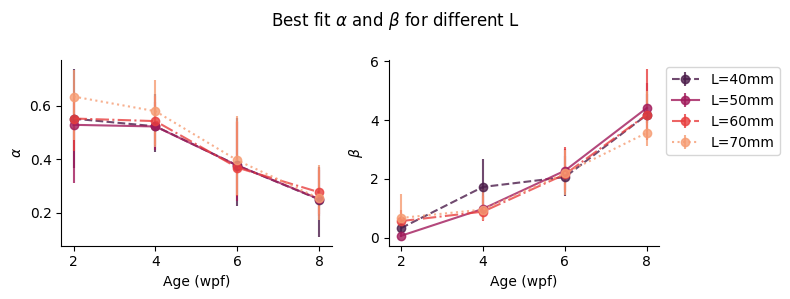

In [ ]:
# plot
fig, ax = plt.subplots(1,2, figsize=(8,3))
colors = sns.color_palette("rocket", n_colors=len(L_list))
linestyles = ["--", "-", "-.", ":"]
for i, L in enumerate(L_list):
    alphas = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,0], 50) for age in fish_ages])
    lower_alpha = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,0], 2.5) for age in fish_ages])
    upper_alpha = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,0], 97.5) for age in fish_ages])
    betas = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,1], 50) for age in fish_ages])
    lower_beta = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,1], 2.5) for age in fish_ages])
    upper_beta = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,1], 97.5) for age in fish_ages])
    ax[0].errorbar(fish_ages, alphas, yerr=[alphas - lower_alpha, upper_alpha - alphas], marker='o', label=f'L={L}mm', color=colors[i], linewidth=1.5, alpha=0.8, linestyle=linestyles[i])
    ax[1].errorbar(fish_ages, betas, yerr=[betas - lower_beta, upper_beta - betas], marker='o', label=f'L={L}mm', color=colors[i], linewidth=1.5, alpha=0.8, linestyle=linestyles[i])
ax[0].set_xlabel('Age (wpf)')
ax[0].set_ylabel(r'$\alpha$')
ax[1].set_xlabel('Age (wpf)')
ax[1].set_ylabel(r'$\beta$')
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1))
fig.suptitle(r'Best fit $\alpha$ and $\beta$ for different L')
fig.tight_layout()

### Fit results are overlapping for $L=40-70$ mm, implying that results are not sensitive to the exact value of $L$.

------

# Additional figure panels from paper

#### Optimal mesoscopic parameters for the full dataset, $L=50$ mm

In [ ]:
i = 1 # L=50mm
indices = delta_t_2_indices[i,:]
alphas = np.mean(alpha_beta_fit_results_all_Ng_all_dt2[i,range(len(fish_ages)),indices,:,0], axis=1)
betas = np.mean(alpha_beta_fit_results_all_Ng_all_dt2[i,range(len(fish_ages)),indices,:,1], axis=1) 
mesoscopic_params_full_dataset = np.column_stack((alphas, betas))

# write to params to file
np.savetxt(f'../../Results/mesoscopic_params_L{L_list[i]}_full_dataset.csv', mesoscopic_params_full_dataset, delimiter=',', header='alpha,beta')

# also note the mesoscopic parameters specifc for each N value
mesoscopic_params_full_dataset_all_Ng = alpha_beta_fit_results_all_Ng_all_dt2[i,range(len(fish_ages)),indices,:,:]

#### Plot optimal parameters (Fig. 2b)

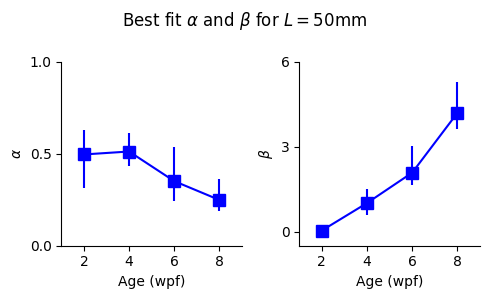

In [ ]:
# plot
fig, ax = plt.subplots(1,2, figsize=(5,3))
i = 1 # L=50mm
L = L_list[i]
alphas = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,0], 50) for age in fish_ages])
lower_alpha = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,0], 2.5) for age in fish_ages])
upper_alpha = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,0], 97.5) for age in fish_ages])
betas = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,1], 50) for age in fish_ages])
lower_beta = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,1], 2.5) for age in fish_ages])
upper_beta = np.array([np.percentile(alpha_beta_fit_results_all_L_all_samples_avg_over_Ng[L][age][:,1], 97.5) for age in fish_ages])
ax[0].errorbar(fish_ages, mesoscopic_params_full_dataset[:,0], yerr=[mesoscopic_params_full_dataset[:,0] - lower_alpha, upper_alpha - mesoscopic_params_full_dataset[:,0]], marker='s', markersize=8, label=f'L={L}mm', color='b', linewidth=1.5, alpha=1)
ax[1].errorbar(fish_ages, mesoscopic_params_full_dataset[:,1], yerr=[mesoscopic_params_full_dataset[:,1] - lower_beta, upper_beta - mesoscopic_params_full_dataset[:,1]], marker='s', markersize=8, label=f'L={L}mm', color='b', linewidth=1.5, alpha=1)
ax[0].set_xlabel('Age (wpf)')
ax[0].set_ylabel(r'$\alpha$')
ax[1].set_xlabel('Age (wpf)')
ax[1].set_ylabel(r'$\beta$')
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].set_ylim([0, 1])
ax[1].set_ylim([-0.5, 6])
ax[0].set_xlim([1, 9])
ax[1].set_xlim([1, 9])
ax[0].set_yticks([0,0.5,1])
ax[1].set_yticks([0,3,6])
fig.suptitle(fr'Best fit $\alpha$ and $\beta$ for $L={L}$mm ')
fig.tight_layout()

#### Jump moments and fit results for 8wpf (Fig. S3)

/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:145: RuntimeWarning: invalid value encountered in sqrt
  for j in range(nbins):
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:146: RuntimeWarning: invalid value encountered in sqrt
  mask = np.logical_and(bin_indices_y==i, bin_indices_x==j)
/Users/palka/Documents/Research/fish-school/data-analysis/danionella-collective-motion/Notebooks/Figure2/../../codebase/parameter_fitting.py:147: RuntimeWarning: invalid value encountered in sqrt
  if np.any(mask):
/var/folders/52/3myd7xrd0fg654krp55x6_zc0000gn/T/ipykernel_18063/4012940697.py:133: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,-1].legend(fontsize=11, loc='upper left', bbox_

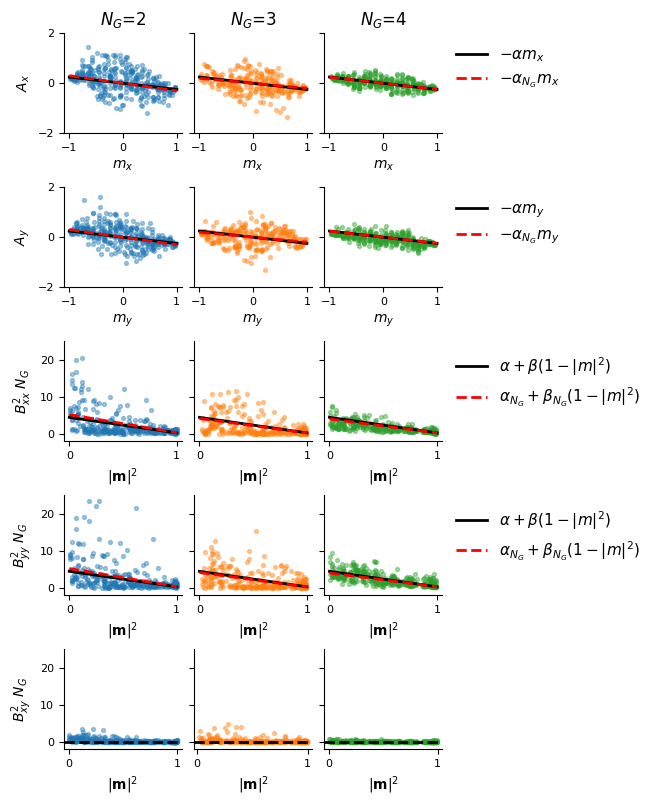

In [ ]:
from codebase.parameter_fitting import _avg_over_m, _Bij_inverse_function
from matplotlib.ticker import MaxNLocator

j = 3 # 8 weeks
age = fish_ages[j]
L = 50 #mm

ylims = [[-2,2], [-2,2], [-2,25], [-2,25],[-2,25]]
yticks = [[-2,0,2], [-2,0,2], [0,10,20], [0,10,20],[0,10,20]]
subgroup_sizes = [2,3,4]
w = 6.5
h = 8
title_size = 12
labelsize = 10
tick_size = 8
markersize=8
fig, ax = plt.subplots(5,3, figsize=(w,h))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for k,Ng in enumerate(Ng_values):
    first_jump_moments = np.vstack([first_jump_moments_all_L[L][age][i][k] for i in range(len(first_jump_moments_all_L[L][age]))])
    second_jump_moments = np.vstack([second_jump_moments_all_L[L][age][i][k] for i in range(len(second_jump_moments_all_L[L][age]))])

    # find averaged values 
    mx_first = _avg_over_m(first_jump_moments[:,0], first_jump_moments[:,1], first_jump_moments[:,0], nbins=20)
    my_first = _avg_over_m(first_jump_moments[:,0], first_jump_moments[:,1], first_jump_moments[:,1], nbins=20)
    dmx = _avg_over_m(first_jump_moments[:,0], first_jump_moments[:,1], first_jump_moments[:,2], nbins=20)
    dmy = _avg_over_m(first_jump_moments[:,0], first_jump_moments[:,1], first_jump_moments[:,3], nbins=20)
    mx_second = _avg_over_m(second_jump_moments[:,0], second_jump_moments[:,1], second_jump_moments[:,0], nbins=20)
    my_second = _avg_over_m(second_jump_moments[:,0], second_jump_moments[:,1], second_jump_moments[:,1], nbins=20)
    m2 = mx_second**2 + my_second**2
    dmxx = _avg_over_m(second_jump_moments[:,0], second_jump_moments[:,1], second_jump_moments[:,2], nbins=20)
    dmyy = _avg_over_m(second_jump_moments[:,0], second_jump_moments[:,1], second_jump_moments[:,3], nbins=20)
    dmxy = _avg_over_m(second_jump_moments[:,0], second_jump_moments[:,1], second_jump_moments[:,4], nbins=20)
    B_xx2, B_yy2, B_xy2 = _Bij_inverse_function(dmxx, dmyy, dmxy)

    params_full_dataset = mesoscopic_params_full_dataset[j,:]
    params_specific_Ng = mesoscopic_params_full_dataset_all_Ng[j,k,:]

    ax[0,k].scatter(mx_first, dmx, s=markersize, color=colors[k], alpha=0.4)
    ax[0,k].plot([-1,1], [params_full_dataset[0], -params_full_dataset[0]], 'k-', label=r'$-\alpha m_x$', linewidth=2)
    ax[0,k].plot([-1,1], [params_specific_Ng[0], -params_specific_Ng[0]], 'r--', label=r'$-\alpha_{N_G} m_x$', linewidth=2)
    ax[0,k].set_xlabel(r'$m_x$', fontsize=labelsize)
    if k==0:
        ax[0,k].set_ylabel(r'$A_x$', fontsize=labelsize)
    ax[0,k].set_ylim(-2,2)
    ax[0,k].set_yticks([-2,-1,0,1,2])
    ax[0,k].set_xticks([-1,0,1])
    ax[0,k].tick_params(axis='both', which='major', labelsize=tick_size)
    # turn off top and right spines
    ax[0,k].spines['top'].set_visible(False)
    ax[0,k].spines['right'].set_visible(False)
    ax[0,k].set_title(f'$N_G$={Ng}', fontsize=title_size)
    # #legend
    # ax[0,k].legend(fontsize=10, loc='upper right', bbox_to_anchor=(1, 1))

    ax[1,k].scatter(my_first, dmy, s=markersize, color=colors[k], alpha=0.4)
    ax[1,k].plot([-1,1], [params_full_dataset[0], -params_full_dataset[0]], 'k-', label=r'$-\alpha m_y$', linewidth=2)
    ax[1,k].plot([-1,1], [params_specific_Ng[0], -params_specific_Ng[0]], 'r--', label=r'$-\alpha_{N_G} m_y$', linewidth=2)
    ax[1,k].set_xlabel(r'$m_y$', fontsize=labelsize)
    if k==0:
        ax[1,k].set_ylabel(r'$A_y$', fontsize=labelsize)
    ax[1,k].set_ylim(-2,2)
    ax[1,k].set_yticks([-2,-1,0,1,2])
    ax[1,k].set_xticks([-1,0,1])
    ax[1,k].tick_params(axis='both', which='major', labelsize=tick_size)
    # turn off top and right spines
    ax[1,k].spines['top'].set_visible(False)
    ax[1,k].spines['right'].set_visible(False)
    #ax[1,k].set_title(f'N={N}', fontsize=14)
    # #legend
    # ax[1,k].legend(fontsize=10, loc='upper right', bbox_to_anchor=(1, 1))

    ax[2,k].scatter(m2, B_xx2*Ng, s=markersize, color=colors[k], alpha=0.4)
    ax[2,k].plot([0,1], [params_full_dataset[0] + params_full_dataset[1], params_full_dataset[0]], 'k-', label=r'$\alpha + \beta(1-|m|^2)$', linewidth=2)
    ax[2,k].plot([0,1], [params_specific_Ng[0] + params_specific_Ng[1], params_specific_Ng[0]], 'r--', label=r'$\alpha_{N_G} + \beta_{N_G}(1-|m|^2)$', linewidth=2)
    xlabel = ax[2,k].set_xlabel(r'$|\mathbf{m}|^2$', fontsize=labelsize)
    xlabel.set_position((0.5, 0.2))
    if k==0:
        ax[2,k].set_ylabel(r'$B_{xx}^2~N_G$', fontsize=labelsize)
    #ax[2,k].set_ylim(ylims[j])
    ax[2,k].yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax[2,k].set_xticks([0,1])
    ax[2,k].tick_params(axis='both', which='major', labelsize=tick_size)
    # turn off top and right spines
    ax[2,k].spines['top'].set_visible(False)
    ax[2,k].spines['right'].set_visible(False)
    #ax[2,k].set_title(f'N={N}', fontsize=14)
    # #legend
    # ax[2,k].legend(fontsize=10, loc='upper right', bbox_to_anchor=(1, 1))

    ax[3,k].scatter(m2, B_yy2*Ng, s=markersize, color=colors[k], alpha=0.4)
    ax[3,k].plot([0,1], [params_full_dataset[0] + params_full_dataset[1], params_full_dataset[0]], 'k-', label=r'$\alpha + \beta(1-|m|^2)$', linewidth=2)
    ax[3,k].plot([0,1], [params_specific_Ng[0] + params_specific_Ng[1], params_specific_Ng[0]], 'r--', label=r'$\alpha_{N_G} + \beta_{N_G}(1-|m|^2)$', linewidth=2)
    xlabel = ax[3,k].set_xlabel(r'$|\mathbf{m}|^2$', fontsize=labelsize)
    xlabel.set_position((0.5, 0.2))
    if k==0:
        ax[3,k].set_ylabel(r'$B_{yy}^2~N_G$', fontsize=labelsize)
    ax[3,k].yaxis.set_major_locator(MaxNLocator(nbins=4))
    #ax[3,k].set_yticks(yticks[j])
    ax[3,k].set_xticks([0,1])
    ax[3,k].tick_params(axis='both', which='major', labelsize=tick_size)
    # turn off top and right spines
    ax[3,k].spines['top'].set_visible(False)
    ax[3,k].spines['right'].set_visible(False)
    #ax[3,k].set_title(f'N={N}', fontsize=14)
    # #legend
    # ax[3,k].legend(fontsize=10, loc='upper right', bbox_to_anchor=(1, 1))

    ax[4,k].scatter(m2, B_xy2*Ng, s=markersize, color=colors[k], alpha=0.4)
    ax[4,k].axhline(0, color='k', linestyle='--', linewidth=2)
    xlabel = ax[4,k].set_xlabel(r'$|\mathbf{m}|^2$', fontsize=labelsize)
    xlabel.set_position((0.5, 0.2))
    if k==0:
        ax[4,k].set_ylabel(r'$B_{xy}^2~N_G$', fontsize=labelsize)
    ax[4,k].yaxis.set_major_locator(MaxNLocator(nbins=4))
    #ax[3,k].set_yticks(yticks[j])
    ax[4,k].set_xticks([0,1])
    ax[4,k].tick_params(axis='both', which='major', labelsize=tick_size)
    # turn off top and right spines
    ax[4,k].spines['top'].set_visible(False)
    ax[4,k].spines['right'].set_visible(False)
    #ax[4,k].set_title(f'N={N}', fontsize=14)

for i in range(5):
    for j in range(3):
        ax[i,j].set_ylim(ylims[i])
        ax[i,j].set_yticks(yticks[i])
        if j>0:
            ax[i,j].set_yticklabels([])

    # legend for last column
    ax[i,-1].legend(fontsize=11, loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
#fig.suptitle('8 weeks', fontsize=16)
fig.tight_layout(pad=0.5)


#### Parameter fits for each $N_G$ from subsamples (Fig. S4)

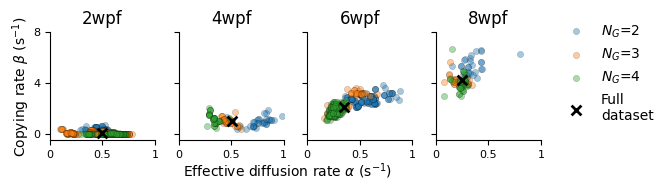

In [ ]:
w = 6.8
h = 1.8
title_size = 12
labelsize = 10
tick_size = 8
markersize= 20
fig, ax =plt.subplots(1,4, figsize=(w,h), sharey=True, sharex=True)
for j, age in enumerate(fish_ages):
    for k,Ng in enumerate(subgroup_sizes):
        ax[j].scatter(alpha_beta_fit_results_all_L_all_ages_all_samples[L][age][k,:,0], alpha_beta_fit_results_all_L_all_ages_all_samples[L][age][k,:,1], s=markersize, color=colors[k], edgecolor='k',alpha=0.4, label=f'$N_G$={Ng}', linewidth=0.25)
    # plot mesoscopic params from full dataset
    ax[j].scatter(mesoscopic_params_full_dataset[j,0], mesoscopic_params_full_dataset[j,1], s=50, color='k', marker='x', label='Full\ndataset', linewidth=2)
    #ax[j].set_xlabel('Effective diffusion rate ' +r'$\alpha$ (1/s)', fontsize=labelsize)
    if j==0:
        ax[j].set_ylabel(r'Copying rate $\beta$ (s$^{-1}$)', fontsize=labelsize, labelpad=1)
    ax[j].set_title(f'{age}wpf', fontsize=title_size)
    ax[j].set_xlim(0,1)
    ax[j].set_ylim(-0.5,8)
    ax[j].set_xticks([0,0.5,1], ["0","0.5","1"])
    ax[j].set_yticks([0,4,8])
    ax[j].tick_params(axis='both', which='major', labelsize=tick_size)
    # legend outside last plot
    if j==3:
        ax[j].legend(bbox_to_anchor=(1.08, 1.2), loc='upper left', fontsize=labelsize, frameon=False)
    # turn off top and right spines
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
# add common x label
fig.text(0.43, -0.01, r'Effective diffusion rate $\alpha$ (s$^{-1}$)', ha='center', fontsize=labelsize)
fig.tight_layout()
